## Owl-ViT

### **Open-World Object Detector with Vision Transformers**

---

Fue desarrollado por Google Research y su nombre significa Open-World Object Detector with Vision Transformers.

Owl-ViT utiliza una arquitectura llamada Vision Transformer (ViT) y se basa en los conocimientos de CLIP (un modelo que entiende la relación entre imágenes y texto).

---
### **Enlace Owl-ViT:**

https://huggingface-co.translate.goog/docs/transformers/model_doc/owlvit?_x_tr_sl=en&_x_tr_tl=es&_x_tr_hl=es&_x_tr_pto=tc

---
**Importante**

* Entrada de Texto: Tú le das una frase (ej: "una taza de café azul").

* Entrada de Imagen: Le pasas la foto.

* Comparación: El modelo escanea la imagen buscando regiones que "coincidan" semánticamente con tu descripción de texto.

* Resultado: Dibuja un cuadro (cuadro delimitador) alrededor de lo que encontró.


In [1]:
!pip uninstall -y tensorflow transformers tf-keras
!pip install -U "tensorflow==2.19.*" "tf-keras==2.19.*" "transformers==4.44.2" datasets evaluate

Found existing installation: tensorflow 2.19.0
Uninstalling tensorflow-2.19.0:
  Successfully uninstalled tensorflow-2.19.0
Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0
Found existing installation: tf_keras 2.19.0
Uninstalling tf_keras-2.19.0:
  Successfully uninstalled tf_keras-2.19.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.5/527.5 kB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 17.1 MB/s eta 0:00:00

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


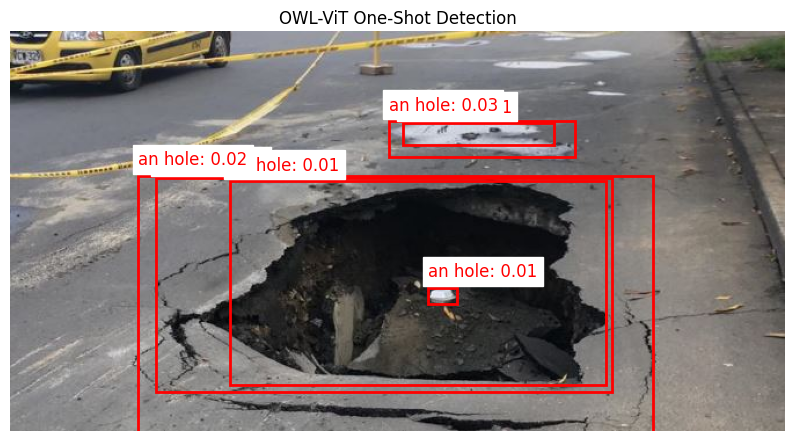

In [14]:
import torch
from transformers import OwlViTProcessor, OwlViTForObjectDetection
from PIL import Image
import requests
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from google.colab import drive


# ---- Load OWL-ViT ----
model = OwlViTForObjectDetection.from_pretrained("google/owlvit-base-patch32")
processor = OwlViTProcessor.from_pretrained("google/owlvit-base-patch32")

# ---- Load image (replace with your own if needed) ----
# Reemplaza con la ruta local de tu imagen
image_path = "/content/drive/MyDrive/Inteligencia Artificial UNAL/Sistemas Inteligentes/Practica/Semana 5/hueco.JPG"
#image_path = "COCO1.jpg"
image = Image.open(image_path).convert("RGB")

#image = Image.open(requests.get(image_url, stream=True).raw).convert("RGB")

# ---- Text prompt for one-shot detection ----
text_prompts = [["an hole"]]


# ---- Preprocess inputs ----
inputs = processor(text=text_prompts, images=image, return_tensors="pt")

# ---- Forward pass ----
with torch.no_grad():
    outputs = model(**inputs)

# ---- Post-process outputs ----
target_sizes = torch.tensor([image.size[::-1]])  # (H, W)
results = processor.post_process_object_detection(outputs=outputs, target_sizes=target_sizes, threshold=0.010)

# ---- Visualization ----
boxes, scores, labels = results[0]["boxes"], results[0]["scores"], results[0]["labels"]

plt.figure(figsize=(10, 10))
plt.imshow(image)
ax = plt.gca()

for box, score, label in zip(boxes, scores, labels):
    xmin, ymin, xmax, ymax = box
    width, height = xmax - xmin, ymax - ymin
    ax.add_patch(patches.Rectangle((xmin, ymin), width, height, linewidth=2, edgecolor='r', facecolor='none'))
    ax.text(xmin, ymin - 10, f"{text_prompts[0][label]}: {score:.2f}", color='red', fontsize=12, backgroundcolor="white")

plt.axis("off")
plt.title("OWL-ViT One-Shot Detection")
plt.show()


## Actividades

* Implementa el código para guardar la imagen resultante con las predicciones.

* Cambia la imagen, el prompt y el umbral (threshold), y observa los resultados.

* Realiza la predicción con una imagen de COCO de Internet utilizando el código sugerido y comenta los resultados.

* Realiza la predicción, pero esta vez con una imagen más compleja o saturada, y comenta los resultados.

* Realiza la predicción con un prompt más largo y comenta el resultado.

* Realiza la predicción con un prompt en español y comenta el resultado.
  

### Punto **N°1**
* Implementa el código para guardar la imagen de segmentación resultante.

In [15]:
def save_owlvit_result(image, results, texts, filename="owlvit_result.png"):
    boxes, scores, labels = results["boxes"], results["scores"], results["labels"]

    plt.figure(figsize=(8,8))
    plt.imshow(image)
    ax = plt.gca()

    for box, score, label in zip(boxes, scores, labels):
        x1, y1, x2, y2 = box.tolist()

        rect = plt.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            edgecolor="red",
            linewidth=2
        )
        ax.add_patch(rect)

        text = f"{texts[label]}: {score:.2f}"
        ax.text(x1, y1, text, color="white", fontsize=10,
                bbox=dict(facecolor="red", alpha=0.5))

    plt.axis("off")

    plt.savefig(filename, bbox_inches="tight", pad_inches=0)
    plt.close()

In [21]:
save_owlvit_result(
    image,
    results[0],
    text_prompts[0],
    "/content/drive/MyDrive/Inteligencia Artificial UNAL/Sistemas Inteligentes/Practica/Semana 5/hueco.JPG"
)

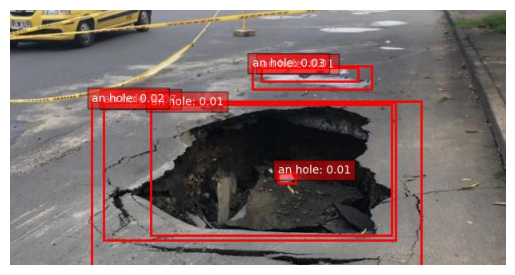

In [22]:
image_path = "/content/drive/MyDrive/Inteligencia Artificial UNAL/Sistemas Inteligentes/Practica/Semana 5/hueco.JPG" # Se debera dejar la ruta, además el nombre del archivo el cual guardaremos.
image = Image.open(image_path)

plt.imshow(image)
plt.axis("off")
plt.show()

### Punto **N°2**
* Cambia la imagen, el prompt del objeto y el umbral, y observa los resultados.
---
**R// Se utilizó la imagen de un muro con un hueco para evaluar como se comporta el modelo y como lo logra reconocer (threshold) a 0.03 para no sesgar tanto al modelo; el modelo entre más bajo sea el threshold detecta más información sobre el muro.**

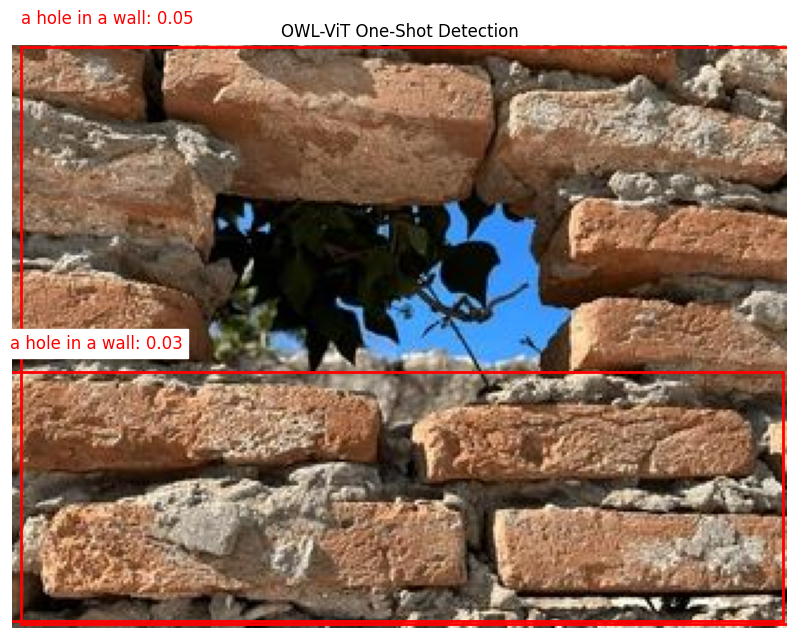

In [31]:
model = OwlViTForObjectDetection.from_pretrained("google/owlvit-base-patch32")
processor = OwlViTProcessor.from_pretrained("google/owlvit-base-patch32")

# ---- Load image (replace with your own if needed) ----
# Reemplaza con la ruta local de tu imagen
image_path = "/content/drive/MyDrive/Inteligencia Artificial UNAL/Sistemas Inteligentes/Practica/Semana 5/muro.JPG"
image = Image.open(image_path).convert("RGB")
text_prompts = [["a hole in a wall"]]

# ---- Preprocess inputs ----
inputs = processor(text=text_prompts, images=image, return_tensors="pt")

# ---- Forward pass ----
with torch.no_grad():
    outputs = model(**inputs)

# ---- Post-process outputs ----
target_sizes = torch.tensor([image.size[::-1]])  # (H, W)
results = processor.post_process_object_detection(outputs=outputs, target_sizes=target_sizes, threshold=0.03)

# ---- Visualization ----
boxes, scores, labels = results[0]["boxes"], results[0]["scores"], results[0]["labels"]

plt.figure(figsize=(10, 10))
plt.imshow(image)
ax = plt.gca()

for box, score, label in zip(boxes, scores, labels):
    xmin, ymin, xmax, ymax = box
    width, height = xmax - xmin, ymax - ymin
    ax.add_patch(patches.Rectangle((xmin, ymin), width, height, linewidth=2, edgecolor='r', facecolor='none'))
    ax.text(xmin, ymin - 10, f"{text_prompts[0][label]}: {score:.2f}", color='red', fontsize=12, backgroundcolor="white")

plt.axis("off")
plt.title("OWL-ViT One-Shot Detection")
plt.show()

### Punto **N°3**
* Realiza la segmentación con una imagen de COCO de Internet y comenta los resultados.
---

**R// Se realizó el analisis de manera exitosa, donde se utilizo el prompt plants `score 0.03`, si el número queda superior a 0.3, por ejemplo 0.31, el modelo generar error.**

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


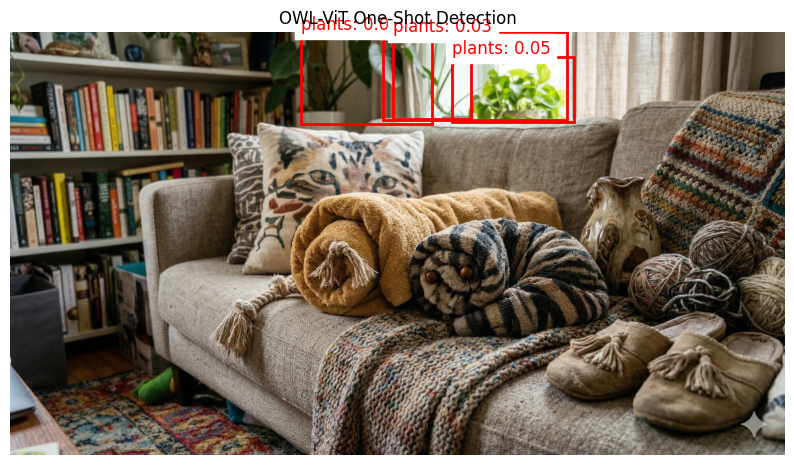

In [34]:
model = OwlViTForObjectDetection.from_pretrained("google/owlvit-base-patch32")
processor = OwlViTProcessor.from_pretrained("google/owlvit-base-patch32")

# ---- Load image (replace with your own if needed) ----
# Reemplaza con la ruta local de tu imagen
image_path = "/content/drive/MyDrive/Inteligencia Artificial UNAL/Sistemas Inteligentes/Practica/Semana 5/dog_2.jpg"
image = Image.open(image_path).convert("RGB")
text_prompts = [["plants"]]

# ---- Preprocess inputs ----
inputs = processor(text=text_prompts, images=image, return_tensors="pt")

# ---- Forward pass ----
with torch.no_grad():
    outputs = model(**inputs)

# ---- Post-process outputs ----
target_sizes = torch.tensor([image.size[::-1]])  # (H, W)
results = processor.post_process_object_detection(outputs=outputs, target_sizes=target_sizes, threshold=0.03)

# ---- Visualization ----
boxes, scores, labels = results[0]["boxes"], results[0]["scores"], results[0]["labels"]

plt.figure(figsize=(10, 10))
plt.imshow(image)
ax = plt.gca()

for box, score, label in zip(boxes, scores, labels):
    xmin, ymin, xmax, ymax = box
    width, height = xmax - xmin, ymax - ymin
    ax.add_patch(patches.Rectangle((xmin, ymin), width, height, linewidth=2, edgecolor='r', facecolor='none'))
    ax.text(xmin, ymin - 10, f"{text_prompts[0][label]}: {score:.2f}", color='red', fontsize=12, backgroundcolor="white")

plt.axis("off")
plt.title("OWL-ViT One-Shot Detection")
plt.show()

### Punto **N°4**

* Realiza la predicción, pero esta vez con una imagen más compleja o saturada, y comenta los resultados.

---

**R// Se utilizó una imagen con mucho ruido para saber el comportamiento del modelo `score 0.45` , y un threshold=0.03 para que el modelo logrará reconocer la información.**

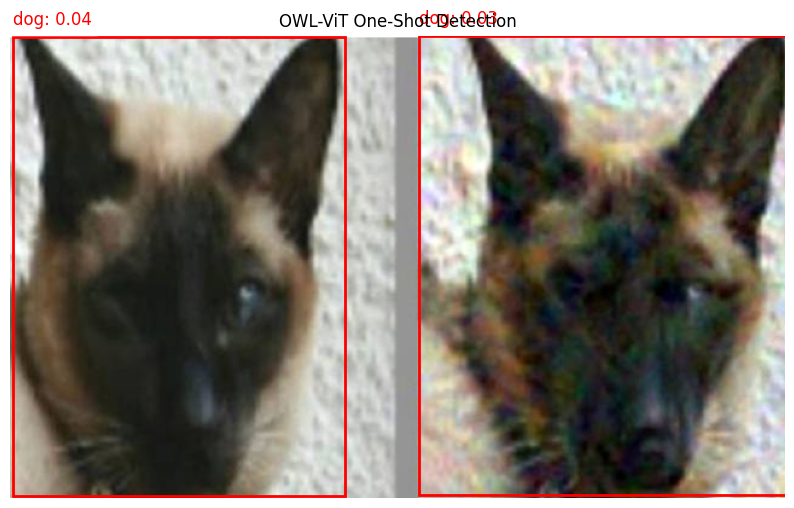

In [40]:
model = OwlViTForObjectDetection.from_pretrained("google/owlvit-base-patch32")
processor = OwlViTProcessor.from_pretrained("google/owlvit-base-patch32")

# ---- Load image (replace with your own if needed) ----
# Reemplaza con la ruta local de tu imagen
image_path = "/content/drive/MyDrive/Inteligencia Artificial UNAL/Sistemas Inteligentes/Practica/Semana 5/gato_perro.jpg"
image = Image.open(image_path).convert("RGB")
text_prompts = [["dog"]]

# ---- Preprocess inputs ----
inputs = processor(text=text_prompts, images=image, return_tensors="pt")

# ---- Forward pass ----
with torch.no_grad():
    outputs = model(**inputs)

# ---- Post-process outputs ----
target_sizes = torch.tensor([image.size[::-1]])  # (H, W)
results = processor.post_process_object_detection(outputs=outputs, target_sizes=target_sizes, threshold=0.03)

# ---- Visualization ----
boxes, scores, labels = results[0]["boxes"], results[0]["scores"], results[0]["labels"]

plt.figure(figsize=(10, 10))
plt.imshow(image)
ax = plt.gca()

for box, score, label in zip(boxes, scores, labels):
    xmin, ymin, xmax, ymax = box
    width, height = xmax - xmin, ymax - ymin
    ax.add_patch(patches.Rectangle((xmin, ymin), width, height, linewidth=2, edgecolor='r', facecolor='none'))
    ax.text(xmin, ymin - 10, f"{text_prompts[0][label]}: {score:.2f}", color='red', fontsize=12, backgroundcolor="white")

plt.axis("off")
plt.title("OWL-ViT One-Shot Detection")
plt.show()

### Punto **N°5**

* Realiza la predicción con un prompt más largo y comenta el resultado.

---

**R// Se utilizó el prompt en español más largo "picture frame, sofa cushion, eyeglasses" y modelo logró reconocer los patrones.**

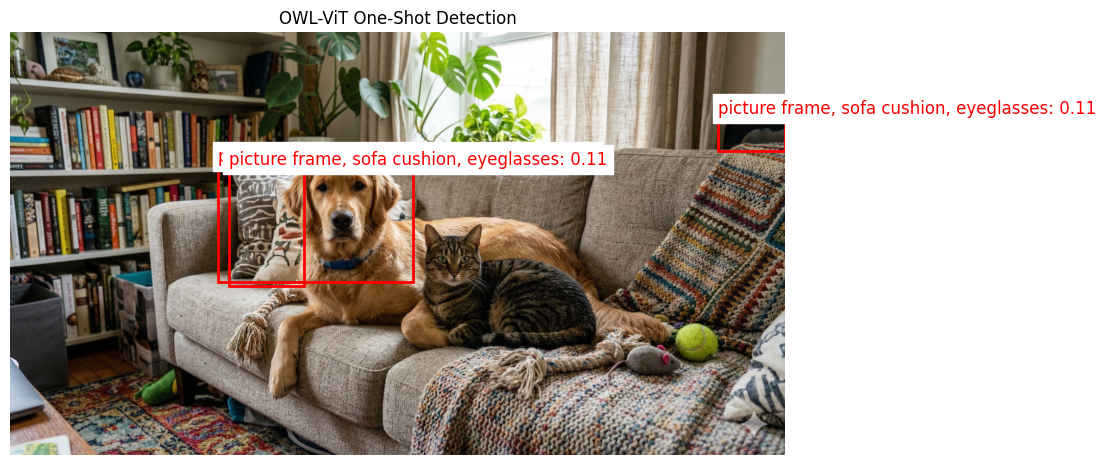

In [45]:
model = OwlViTForObjectDetection.from_pretrained("google/owlvit-base-patch32")
processor = OwlViTProcessor.from_pretrained("google/owlvit-base-patch32")

# ---- Load image (replace with your own if needed) ----
# Reemplaza con la ruta local de tu imagen
image_path = "/content/drive/MyDrive/Inteligencia Artificial UNAL/Sistemas Inteligentes/Practica/Semana 5/dog.jpg"
image = Image.open(image_path).convert("RGB")
text_prompts = [["picture frame, sofa cushion, eyeglasses"]]

# ---- Preprocess inputs ----
inputs = processor(text=text_prompts, images=image, return_tensors="pt")

# ---- Forward pass ----
with torch.no_grad():
    outputs = model(**inputs)

# ---- Post-process outputs ----
target_sizes = torch.tensor([image.size[::-1]])  # (H, W)
results = processor.post_process_object_detection(outputs=outputs, target_sizes=target_sizes, threshold=0.09)

# ---- Visualization ----
boxes, scores, labels = results[0]["boxes"], results[0]["scores"], results[0]["labels"]

plt.figure(figsize=(10, 10))
plt.imshow(image)
ax = plt.gca()

for box, score, label in zip(boxes, scores, labels):
    xmin, ymin, xmax, ymax = box
    width, height = xmax - xmin, ymax - ymin
    ax.add_patch(patches.Rectangle((xmin, ymin), width, height, linewidth=2, edgecolor='r', facecolor='none'))
    ax.text(xmin, ymin - 10, f"{text_prompts[0][label]}: {score:.2f}", color='red', fontsize=12, backgroundcolor="white")

plt.axis("off")
plt.title("OWL-ViT One-Shot Detection")
plt.show()

### Punto **N°7**

* Realiza la predicción con un prompt en español y comenta el resultado.

---

**R// Al momento de utilizar el prompt en ESP el modelo no logró reconocer ningún patrón.**

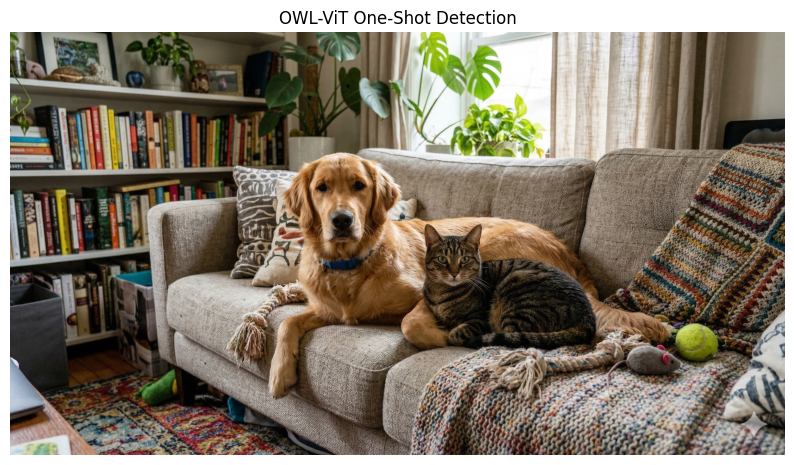

In [46]:
model = OwlViTForObjectDetection.from_pretrained("google/owlvit-base-patch32")
processor = OwlViTProcessor.from_pretrained("google/owlvit-base-patch32")

# ---- Load image (replace with your own if needed) ----
# Reemplaza con la ruta local de tu imagen
image_path = "/content/drive/MyDrive/Inteligencia Artificial UNAL/Sistemas Inteligentes/Practica/Semana 5/dog.jpg"
image = Image.open(image_path).convert("RGB")
text_prompts = [["Un perro en el sofa"]]

# ---- Preprocess inputs ----
inputs = processor(text=text_prompts, images=image, return_tensors="pt")

# ---- Forward pass ----
with torch.no_grad():
    outputs = model(**inputs)

# ---- Post-process outputs ----
target_sizes = torch.tensor([image.size[::-1]])  # (H, W)
results = processor.post_process_object_detection(outputs=outputs, target_sizes=target_sizes, threshold=0.09)

# ---- Visualization ----
boxes, scores, labels = results[0]["boxes"], results[0]["scores"], results[0]["labels"]

plt.figure(figsize=(10, 10))
plt.imshow(image)
ax = plt.gca()

for box, score, label in zip(boxes, scores, labels):
    xmin, ymin, xmax, ymax = box
    width, height = xmax - xmin, ymax - ymin
    ax.add_patch(patches.Rectangle((xmin, ymin), width, height, linewidth=2, edgecolor='r', facecolor='none'))
    ax.text(xmin, ymin - 10, f"{text_prompts[0][label]}: {score:.2f}", color='red', fontsize=12, backgroundcolor="white")

plt.axis("off")
plt.title("OWL-ViT One-Shot Detection")
plt.show()